# Using Y-factor method with two-stage system to measure noise temperature and gain

In [15]:
# import necessary modules
import os
from os.path import join as pjoin
import numpy as np
from matplotlib import pyplot as plt

# global matplotlib style defaults
from highz_exp.plotter import set_matplotlib_defaults

set_matplotlib_defaults()

pjoin = os.path.join
pbase = os.path.basename

%load_ext autoreload
%autoreload 2

# import relevant classes from highz_exp
from highz_exp.fit_temperature import Y_Factor_Thermometer
from highz_exp.spec_class import Spectrum
from highz_exp import plotter

# set up data paths
data_path = os.path.expanduser("~/Desktop/High-Z/LNA_Measurements") # change this to your data directory
output_path = pjoin(data_path, 'Processed') # change this to your desired output directory
plot_path = pjoin(data_path, 'Plots') # change this to your desired plot directory
sparam_path = os.path.expanduser("~/Desktop/High-Z/S21Measurements") # change this to your S-parameter data directory

if os.path.exists(output_path) is False:
    os.makedirs(output_path)
if os.path.exists(plot_path) is False:
    os.makedirs(plot_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
def lna_temp_model(frequency, a, b, c):
    """LNA temperature model: T(f) = a/f + b + c*f.

    Parameters
    ----------
    frequency : np.ndarray
        Frequency axis (any unit). Parameters are fit in the same unit basis.
    a, b, c : float
        Model coefficients.
    """
    frequency = np.asarray(frequency, dtype=float)
    return a / frequency + b + c * frequency


def fit_lna_temperature(frequency, temperature, method='scipy', initial_guess=None):
    """Fit LNA temperature using T(f) = a/f + b + c*f.

    Parameters
    ----------
    frequency : np.ndarray
        Frequency axis; values must be non-zero.
    temperature : np.ndarray
        Temperature values in Kelvin.
    method : str, optional
        Fit backend: 'scipy' (nonlinear least squares) or 'numpy' (linear least squares).
    initial_guess : tuple[float, float, float], optional
        Initial guess for scipy fit: (a, b, c).

    Returns
    -------
    dict
        Dictionary with keys: 'a', 'b', 'c', 'fitted', 'residuals', 'r2', 'covariance'.
        Covariance is None for method='numpy'.
    """
    from scipy.optimize import curve_fit
    frequency = np.asarray(frequency, dtype=float)
    temperature = np.asarray(temperature, dtype=float)

    valid = np.isfinite(frequency) & np.isfinite(temperature) & (frequency != 0)
    f = frequency[valid]
    t = temperature[valid]

    if f.size < 3:
        raise ValueError('Need at least 3 valid samples to fit a/f + b + c*f.')

    method = method.lower()
    if method == 'numpy':
        design = np.column_stack([1.0 / f, np.ones_like(f), f])
        coeffs, _, _, _ = np.linalg.lstsq(design, t, rcond=None)
        a, b, c = coeffs
        covariance = None
    elif method == 'scipy':
        if initial_guess is None:
            f_med = np.nanmedian(f)
            t_med = np.nanmedian(t)
            initial_guess = (t_med * f_med, t_med, 0.0)
        coeffs, covariance = curve_fit(
            lna_temp_model,
            f,
            t,
            p0=initial_guess,
            maxfev=20000,
        )
        a, b, c = coeffs
    else:
        raise ValueError("method must be 'scipy' or 'numpy'.")

    fitted = lna_temp_model(f, a, b, c)
    residuals = t - fitted
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((t - np.mean(t))**2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

    return {
        'a': float(a),
        'b': float(b),
        'c': float(c),
        'fitted': fitted,
        'residuals': residuals,
        'r2': float(r2),
        'covariance': covariance,
        'valid_mask': valid,
    }



In [2]:
# Import data loading module, this is used to parse CSV files from Keysight spectrum analyzer.
from highz_exp import load_csv

# load data for 300K-77K measurements
file_LNA = pjoin(data_path, 'LNA12.csv')
load_csv.split_csv_by_trace_name(file_LNA, 
                                 header_file=pjoin(output_path, 'LNA12_header.csv'),
                                 data_file= pjoin(output_path, 'LNA12_data.csv'))

# parse data files into separate traces
traces_LNA = load_csv.parse_trace_data(pjoin(output_path, 'LNA12_data.csv'))
sys_300K = Spectrum(traces_LNA['Trace A']['frequency'], traces_LNA['Trace A']['spectrum'], 
                      name='300K load - LNA12')
sys_77K = Spectrum(traces_LNA['Trace B']['frequency'], traces_LNA['Trace B']['spectrum'], 
                       name='BB013')
LNA_300K = Spectrum(traces_LNA['Trace C']['frequency'], traces_LNA['Trace C']['spectrum'], 
                       name='BB016')
LNA_77K = Spectrum(traces_LNA['Trace D']['frequency'], traces_LNA['Trace D']['spectrum'], 
                     name='77K load - LNA12')

Split complete:
  Header file: /Users/yuntongzhou/Desktop/High-Z/LNA_Measurements/Processed/LNA12_header.csv (30 rows)
  Data file: /Users/yuntongzhou/Desktop/High-Z/LNA_Measurements/Processed/LNA12_data.csv (755 rows)
Found 4 traces: ['Trace A', 'Trace B', 'Trace C', 'Trace D']
Column pairs: [(0, 1), (2, 3), (4, 5), (6, 7)]
'Trace Data' found at row 3
Trace 'Trace A': parsed 751 data points
Trace 'Trace B': parsed 751 data points
Trace 'Trace C': parsed 751 data points
Trace 'Trace D': parsed 751 data points
Successfully parsed 4 traces with data


We need to calculate the system gain and noise temperature first, with 77 Kelvin and 300 Kelvin 50 Ohm loads as the hot and cold sources. To do this, we first convert all the measurements from log scale to linear scale. 

Here we'll use a `Y_Factor_Thermometer` class from the `highz_exp` package, which has the functionalities to calculate and plot the noise temperature and gain of the LNA based on the hot-cold measurements.

In [3]:
# Convert the hot-cold measurements from dBm to milliwatt
dut_hot = LNA_300K.unit_convert('dBm', 'milliwatt', channel_width=1e6).despike(threshold=20, window=50).spec
dut_cold = LNA_77K.unit_convert('dBm', 'milliwatt', channel_width=1e6).despike(threshold=20, window=50).spec
cal_hot = sys_300K.unit_convert('dBm', 'milliwatt', channel_width=1e6).despike(threshold=20, window=50).spec
cal_cold = sys_77K.unit_convert('dBm', 'milliwatt', channel_width=1e6).despike(threshold=20, window=50).spec

# construct the Y-Factor thermometer object, 
# this has the functionalities to calculate and plot the noise temperature and gain of the LNA 
# based on the hot-cold measurements
LNA_thermo = Y_Factor_Thermometer(LNA_300K.freq, dut_hot, dut_cold,
                                    DUT_name='LNA12', T_hot=301, T_cold=77, RBW=1e6, 
                                    cal_hot=cal_hot, cal_cold=cal_cold)

LNA_thermo.smooth(inplace=True)

# New frequency binned
new_freq = np.arange(25e6, 500e6, 5e6)
LNA_thermo.resample(new_freq)

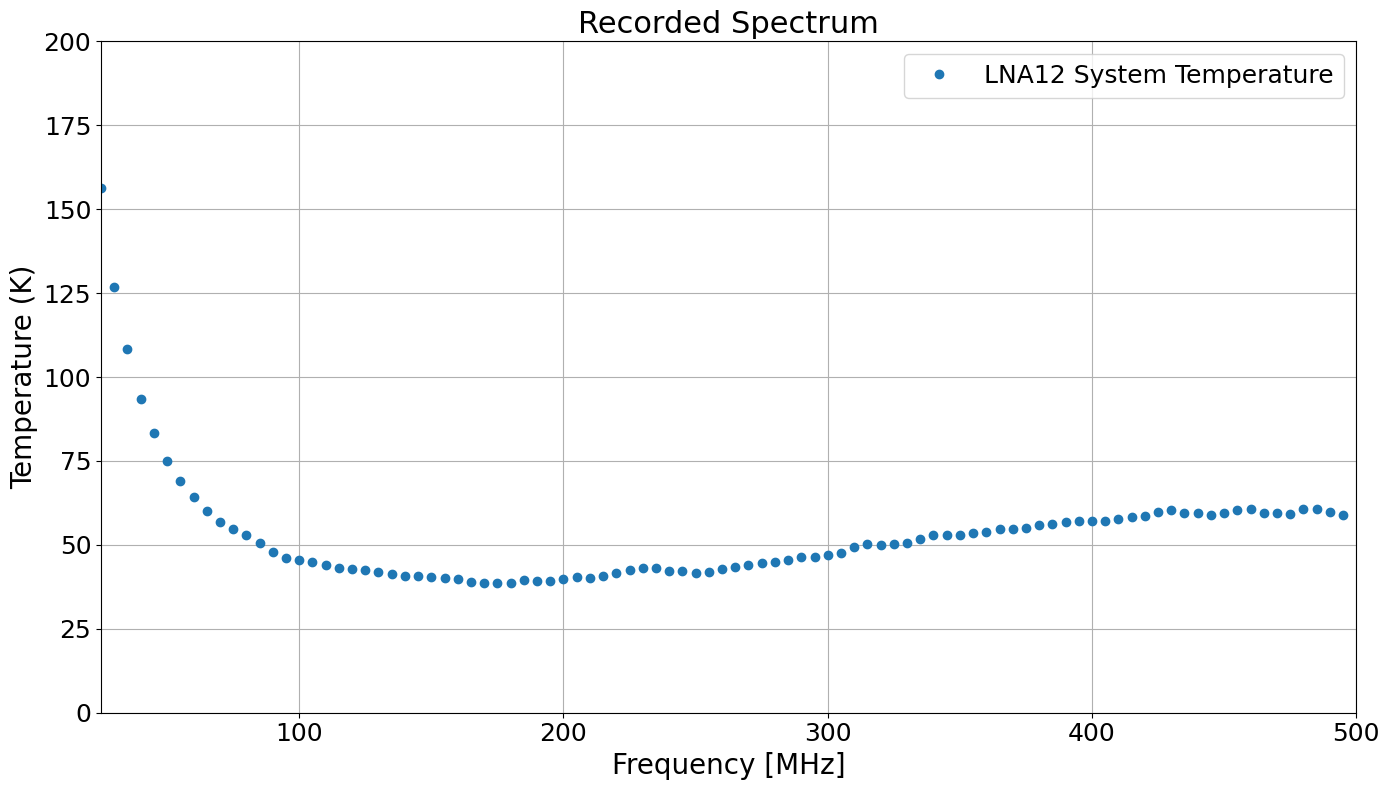

In [5]:
LNA_thermo.plot_system_temperature(freq_range=(25, 500), y_range=(0, 200),
                                   marker='o', linestyle='')

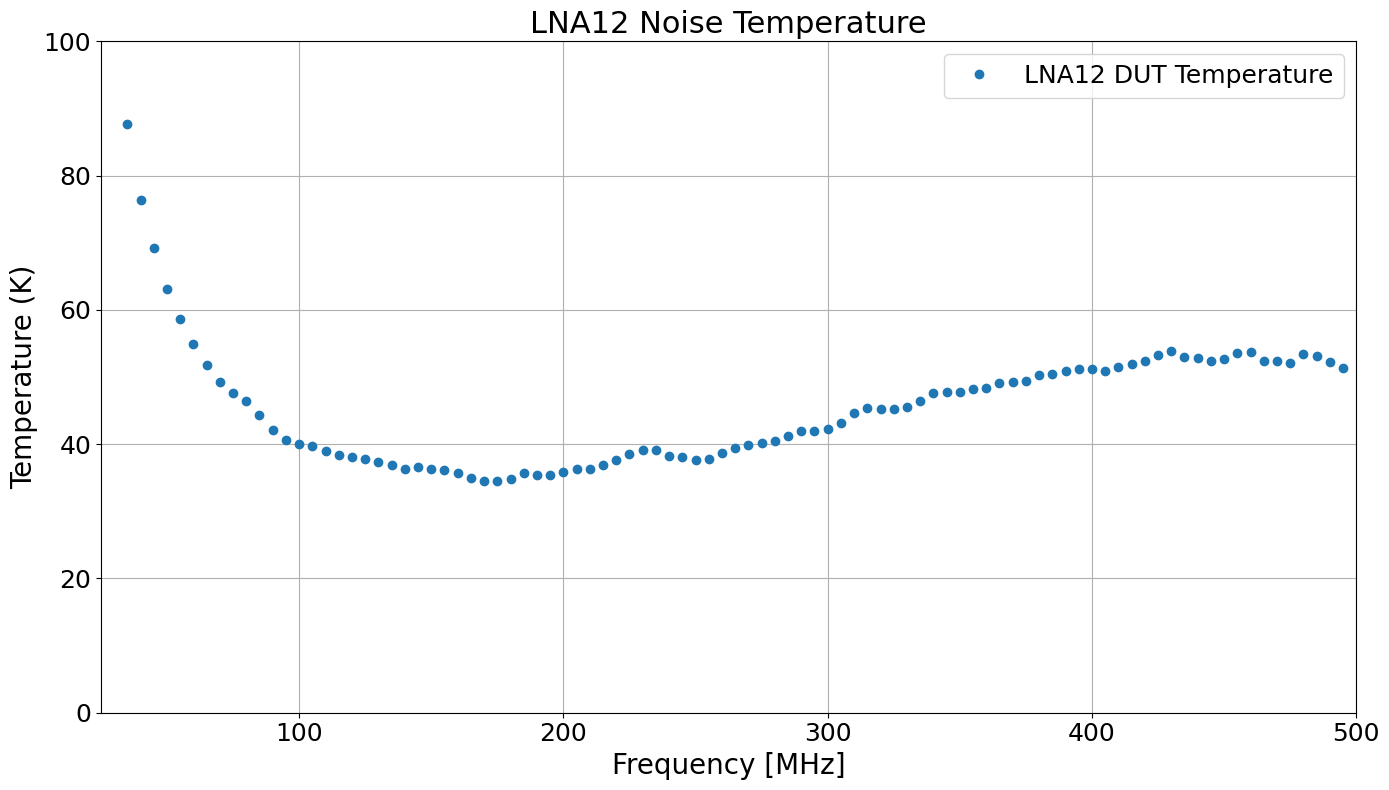

In [6]:
LNA_thermo.plot_dut_temperature(freq_range=(25, 500), y_range=(0, 100),
                               marker='o', linestyle='', 
                               title='LNA12 Noise Temperature', save_path=pjoin(plot_path, 'LNA12_noise_temp.png'))

Fit parameters: a=2.90109e+09, b=1.68294, c=1.0167e-07, R^2=0.98274


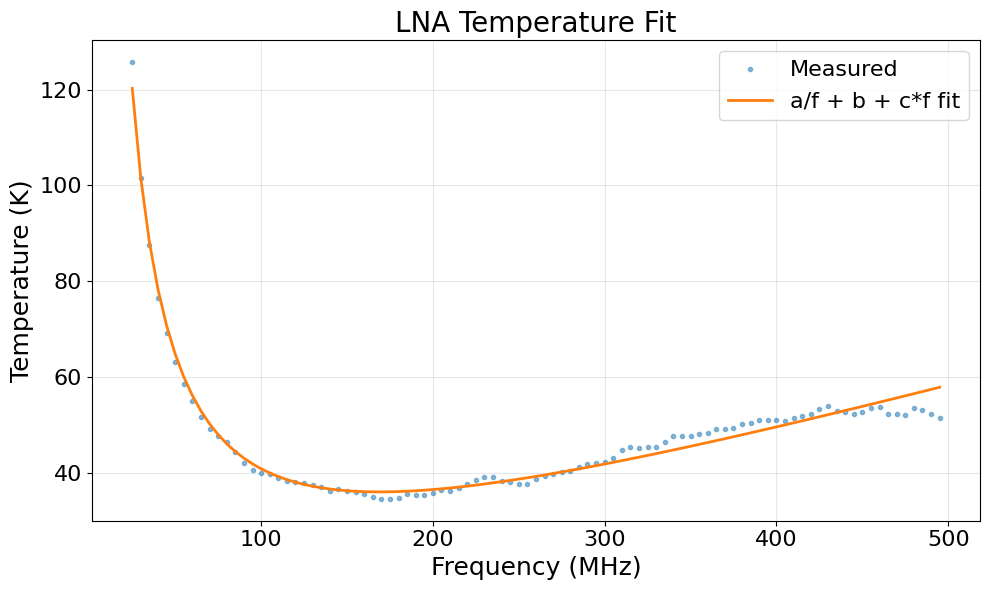

In [13]:
# Fit T(f) = a/f + b + c*f to the LNA temperature curve
f_fit = np.asarray(LNA_thermo.f, dtype=float)  # Hz
t_fit = np.asarray(LNA_thermo.T_dut if LNA_thermo.T_dut is not None else LNA_thermo.T_sys, dtype=float)

fit_res = fit_lna_temperature(f_fit, t_fit, method='scipy')
a, b, c = fit_res['a'], fit_res['b'], fit_res['c']
print(f"Fit parameters: a={a:.6g}, b={b:.6g}, c={c:.6g}, R^2={fit_res['r2']:.5f}")

valid = fit_res['valid_mask']
f_valid_hz = f_fit[valid]
t_valid = t_fit[valid]
t_model = lna_temp_model(f_valid_hz, a, b, c)

plt.figure(figsize=(10, 6))
plt.plot(f_valid_hz / 1e6, t_valid, 'o', ms=3, alpha=0.5, label='Measured')
plt.plot(f_valid_hz / 1e6, t_model, '-', lw=2, label='a/f + b + c*f fit')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Temperature (K)')
plt.title('LNA Temperature Fit')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

20-250 MHz fit: a=3.02893e+09, b=-1.90476, c=1.15553e-07, R^2=0.99723


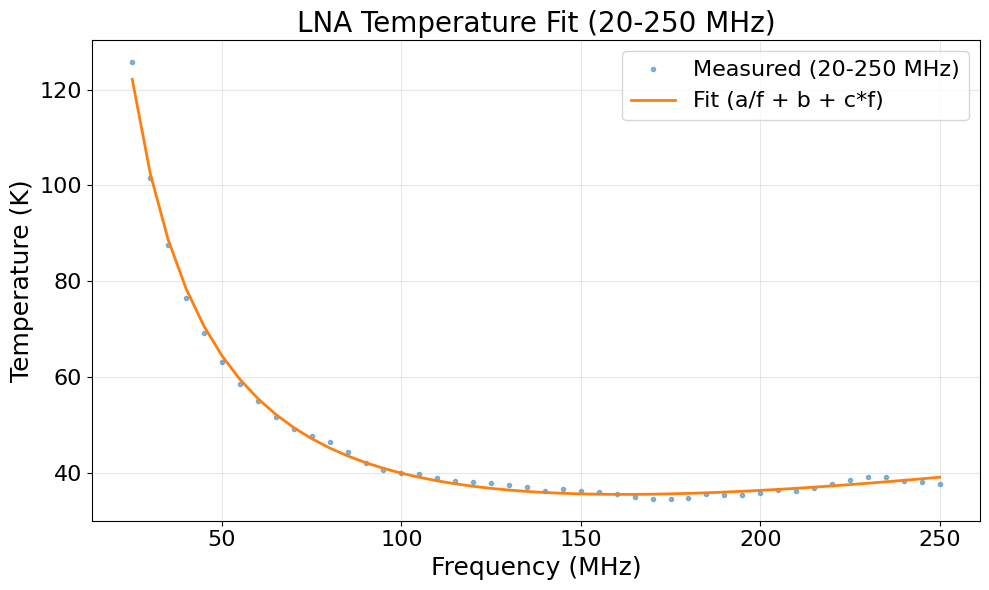

In [14]:
# Fit only in 20-250 MHz for T(f) = a/f + b + c*f
fmin_mhz, fmax_mhz = 20.0, 250.0
band_mask = (f_fit / 1e6 >= fmin_mhz) & (f_fit / 1e6 <= fmax_mhz)

f_band = f_fit[band_mask]
t_band = t_fit[band_mask]

fit_res_band = fit_lna_temperature(f_band, t_band, method='scipy')
a_band, b_band, c_band = fit_res_band['a'], fit_res_band['b'], fit_res_band['c']
print(
    f"20-250 MHz fit: a={a_band:.6g}, b={b_band:.6g}, c={c_band:.6g}, R^2={fit_res_band['r2']:.5f}"
)

valid_band = fit_res_band['valid_mask']
f_band_valid_hz = f_band[valid_band]
t_band_valid = t_band[valid_band]
t_band_model = lna_temp_model(f_band_valid_hz, a_band, b_band, c_band)

plt.figure(figsize=(10, 6))
plt.plot(f_band_valid_hz / 1e6, t_band_valid, 'o', ms=3, alpha=0.5, label='Measured (20-250 MHz)')
plt.plot(f_band_valid_hz / 1e6, t_band_model, '-', lw=2, label='Fit (a/f + b + c*f)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Temperature (K)')
plt.title('LNA Temperature Fit (20-250 MHz)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Export fit parameters to JSON for reuse in other notebooks
import json

fit_export = {
    'model_full': {
        'form': 'a/f + b + c*f',
        'frequency_unit': 'Hz',
        'fit_range_mhz': [float(np.min(f_fit) / 1e6), float(np.max(f_fit) / 1e6)],
        'a': float(a),
        'b': float(b),
        'c': float(c),
        'r2': float(fit_res['r2']),
    },
    'model_20_250': {
        'form': 'a/f + b + c*f',
        'frequency_unit': 'Hz',
        'fit_range_mhz': [20.0, 250.0],
        'a': float(a_band),
        'b': float(b_band),
        'c': float(c_band),
        'r2': float(fit_res_band['r2']),
    }
}

export_file = pjoin(output_path, 'lna_temperature_fit_params.json')
with open(export_file, 'w') as f:
    json.dump(fit_export, f, indent=2)

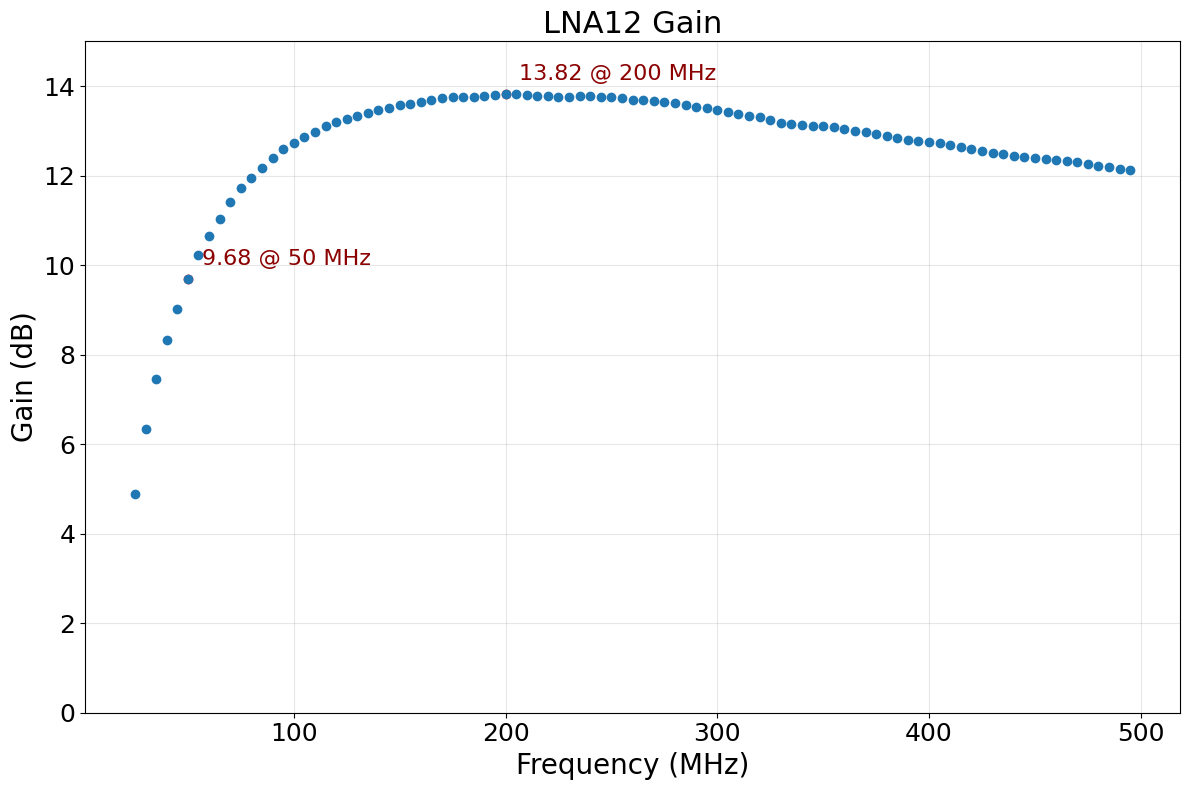

In [27]:
LNA_thermo.plot_gain(marker='o', linestyle='', title='LNA12 Gain',
                     y_range=(0, 15), 
                     save_path=pjoin(plot_path, 'LNA12_gain.png'),
                     marker_freqs=[50, 200])

From the measured power spectrum of the calibrators loads after LNA, we can infer their input temperature.